# 03 — EDA & Visualization
exploring wikipedia traffic and reddit engagement patterns around AI.

the big question: can we see chatgpt's impact (nov 30, 2022) in the data?

In [7]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from wordcloud import WordCloud
from src.data_prep import add_pre_post_chatgpt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

# load data
pageviews = pd.read_csv('../../data/processed/en_wiki_pageviews_yearly.csv')
reddit = pd.read_csv('../../data/raw/reddit_raw/reddit_ai_wikipedia_posts.csv')

reddit['date'] = pd.to_datetime(reddit['date'])
pageviews['timestamp'] = pd.to_datetime(pageviews['timestamp'])

# chatgpt launch date
CHATGPT_LAUNCH = pd.Timestamp("2022-11-30")

In [8]:
# before vs after comparison — average monthly views per article
pageviews_tagged = add_pre_post_chatgpt(pageviews, date_col="timestamp")

comparison = pageviews_tagged.groupby(["article", "period"])["views"].mean().unstack()
comparison["change_pct"] = ((comparison["post-ChatGPT"] - comparison["pre-ChatGPT"]) / comparison["pre-ChatGPT"] * 100).round(1)
comparison = comparison.sort_values("change_pct", ascending=False)

print("average monthly pageviews — before vs after chatgpt launch:")
print(comparison.to_string())

KeyError: 'article'

## 3. Reddit Post Volume & Engagement

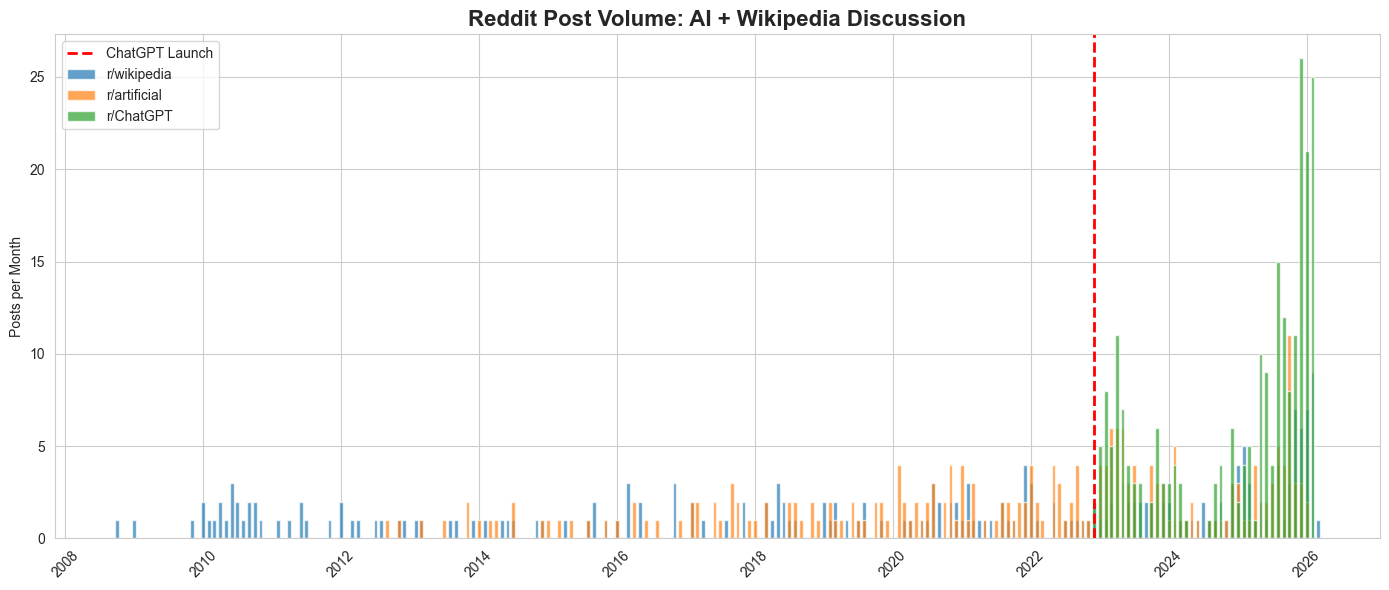

In [9]:
# posts per month by subreddit
reddit["month"] = reddit["date"].dt.to_period("M").dt.to_timestamp()

monthly_posts = reddit.groupby(["month", "subreddit"]).size().reset_index(name="post_count")

fig, ax = plt.subplots(figsize=(14, 6))
for sub in monthly_posts["subreddit"].unique():
    data = monthly_posts[monthly_posts["subreddit"] == sub]
    ax.bar(data["month"], data["post_count"], label=f"r/{sub}", alpha=0.7, width=20)

ax.axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2, label="ChatGPT Launch")
ax.set_title("Reddit Post Volume: AI + Wikipedia Discussion", fontsize=16, fontweight="bold")
ax.set_ylabel("Posts per Month")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../reports/reddit_reports/reddit_volume.png", dpi=150, bbox_inches="tight")
plt.show()

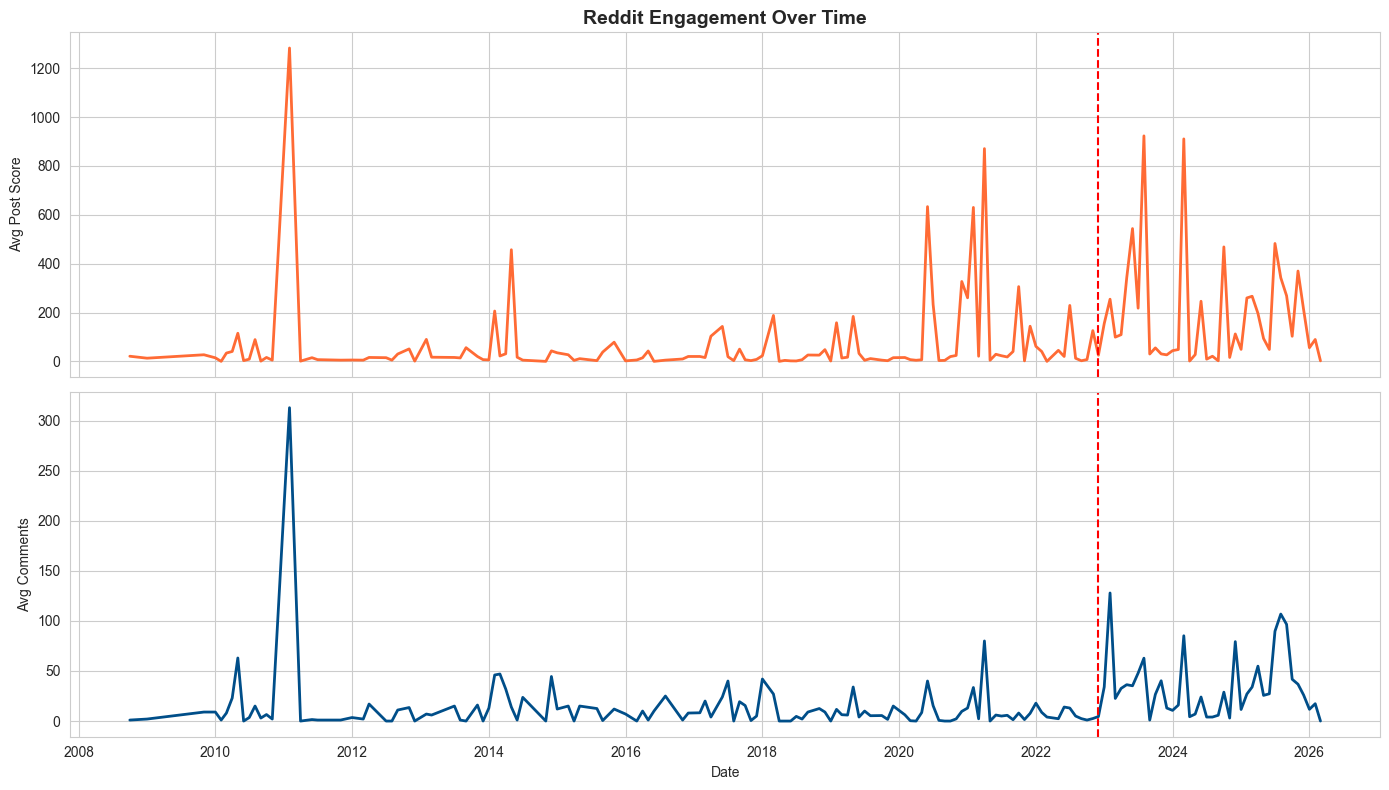

In [10]:
# engagement — average score and comments over time
monthly_engagement = reddit.groupby("month").agg(
    avg_score=("score", "mean"),
    avg_comments=("num_comments", "mean"),
    total_posts=("score", "count")
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(monthly_engagement["month"], monthly_engagement["avg_score"], color="#FF6B35", linewidth=2)
ax1.axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=1.5)
ax1.set_ylabel("Avg Post Score")
ax1.set_title("Reddit Engagement Over Time", fontsize=14, fontweight="bold")

ax2.plot(monthly_engagement["month"], monthly_engagement["avg_comments"], color="#004E89", linewidth=2)
ax2.axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=1.5)
ax2.set_ylabel("Avg Comments")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.savefig("../../reports/reddit_reports/reddit_engagement.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# top posts by engagement — the most heated discussions
top_posts = reddit.nlargest(15, "score")[["title", "subreddit", "score", "num_comments", "date"]]
print("top 15 posts by upvotes:")
top_posts

top 15 posts by upvotes:


,title,subreddit,score,num_comments,date
231,Ok what?,ChatGPT,4152,198,2024-03-20 12:37:56
219,Wikipedia looks so lonely…,ChatGPT,3923,98,2023-06-16 07:40:14
236,Maybe it's time to scale down classroom sizes ...,ChatGPT,3840,232,2023-08-20 00:10:57
257,It just makes up some lol,ChatGPT,3640,117,2023-05-28 01:31:17
222,I Tested OpenAI's $20/month “Agent” So You Don...,ChatGPT,3269,506,2025-07-25 21:44:51
1,Elizabeth Ann Roberts is an American model who...,wikipedia,3204,125,2025-12-09 17:11:44
0,"Aziz Sergeyevich Shavershian (1989–2011), bett...",wikipedia,3075,245,2025-11-12 09:41:04
8,"During the World War II, conventional Allied i...",wikipedia,2782,37,2024-10-17 12:47:18
221,ChatGPT-5 Tries to gaslight me that the Luigi ...,ChatGPT,2556,929,2025-08-26 12:40:05
223,Where AI gets its facts,ChatGPT,2451,604,2025-08-20 18:30:23
